In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
df = pd.read_csv("C:/Users/janua/Downloads/job_salary_prediction_dataset.csv")
df

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069
...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17,PhD,2,Telecom,Enterprise,India,No,1,127791
249996,Frontend Developer,20,PhD,7,Telecom,Startup,Remote,No,2,154593
249997,Business Analyst,1,Bachelor,12,Retail,Enterprise,India,Yes,0,75988
249998,Data Scientist,0,High School,2,Consulting,Small,Sweden,Hybrid,5,90467


In [6]:
print("Shape:", df.shape)

Shape: (250000, 10)


In [7]:
df.describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   job_title         250000 non-null  str  
 1   experience_years  250000 non-null  int64
 2   education_level   250000 non-null  str  
 3   skills_count      250000 non-null  int64
 4   industry          250000 non-null  str  
 5   company_size      250000 non-null  str  
 6   location          250000 non-null  str  
 7   remote_work       250000 non-null  str  
 8   certifications    250000 non-null  int64
 9   salary            250000 non-null  int64
dtypes: int64(4), str(6)
memory usage: 19.1 MB


In [9]:
df.columns

Index(['job_title', 'experience_years', 'education_level', 'skills_count',
       'industry', 'company_size', 'location', 'remote_work', 'certifications',
       'salary'],
      dtype='str')

In [10]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [11]:
df.isnull().sum()

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

In [12]:
df=df.fillna(df.mean(numeric_only=True), inplace=True)
df

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069
...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17,PhD,2,Telecom,Enterprise,India,No,1,127791
249996,Frontend Developer,20,PhD,7,Telecom,Startup,Remote,No,2,154593
249997,Business Analyst,1,Bachelor,12,Retail,Enterprise,India,Yes,0,75988
249998,Data Scientist,0,High School,2,Consulting,Small,Sweden,Hybrid,5,90467


In [13]:
# Creating X and y
x = df['experience_years']
x =np.array(x)
# Convert to 2D
x = x.reshape(-1, 1) 
y = df['salary']

In [14]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.7,
                                                     test_size=0.3, random_state=100)

In [15]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [50]:
# To get the intercept value b0
b0=regressor.intercept_
# To get the coefficient value b1
b1=regressor.coef_
print("Intercept:",b0, "Coefficient:",b1)
y=b0+b1*x
y


Intercept: 118633.22278869993 Coefficient: [2703.32233672]


array([[145666.4461559 ],
       [132149.8344723 ],
       [167293.02484965],
       ...,
       [121336.54512542],
       [118633.2227887 ],
       [161886.38017621]], shape=(250000, 1))

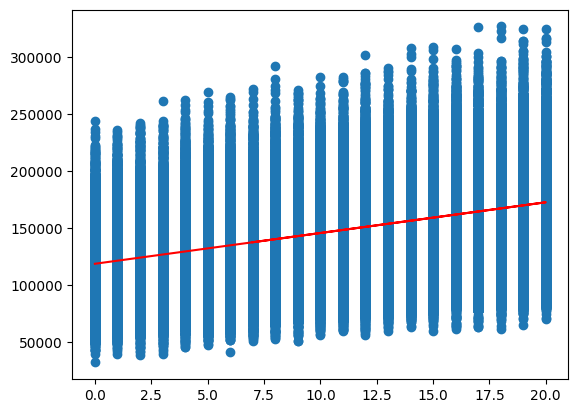

In [20]:
# Visualizing the regression line
plt.scatter(x_train, y_train)
plt.plot(x_train, 118633.222 + 2703.322*x_train, 'r')
plt.show()

In [21]:
y_pred = regressor.predict(x_test)

results = pd.DataFrame({
    'Actual': y_test[:5].values,
    'Predicted': y_pred[:5]
})
print(results)

   Actual      Predicted
0  234706  169996.347186
1  137011  145666.446156
2  169886  145666.446156
3  176147  142963.123819
4  175686  153776.413166


In [22]:
from sklearn import metrics
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Mean Absolute Error: 26518.30219829235
Mean Squared Error: 1128245596.2210617
Root Mean Squared Error: 33589.36730903191


In [23]:
from sklearn.metrics import r2_score
r_squared = r2_score(y_test, y_pred)
r_squared


0.19132987372633758

In [24]:
df.to_csv('job_salary_prediction_dataset_saved', index=False)

In [25]:
df

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069
...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17,PhD,2,Telecom,Enterprise,India,No,1,127791
249996,Frontend Developer,20,PhD,7,Telecom,Startup,Remote,No,2,154593
249997,Business Analyst,1,Bachelor,12,Retail,Enterprise,India,Yes,0,75988
249998,Data Scientist,0,High School,2,Consulting,Small,Sweden,Hybrid,5,90467


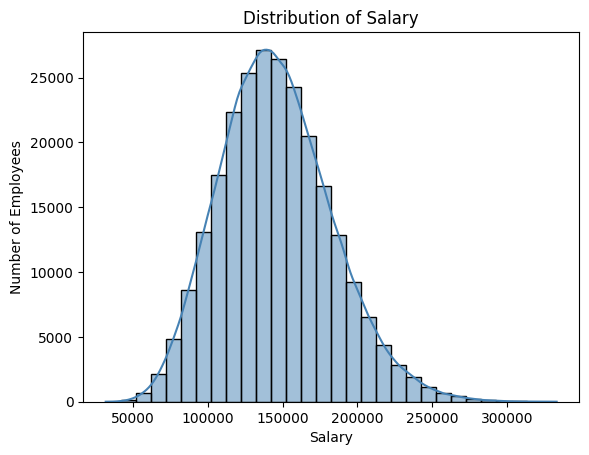

In [26]:
plt.figure()
sns.histplot(df['salary'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of Salary')
plt.xlabel('Salary')
plt.ylabel('Number of Employees')
plt.show()

C:\Users\janua\AppData\Local\Temp\ipykernel_49020\692062404.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=job_counts.values, y=job_counts.index, palette='viridis')


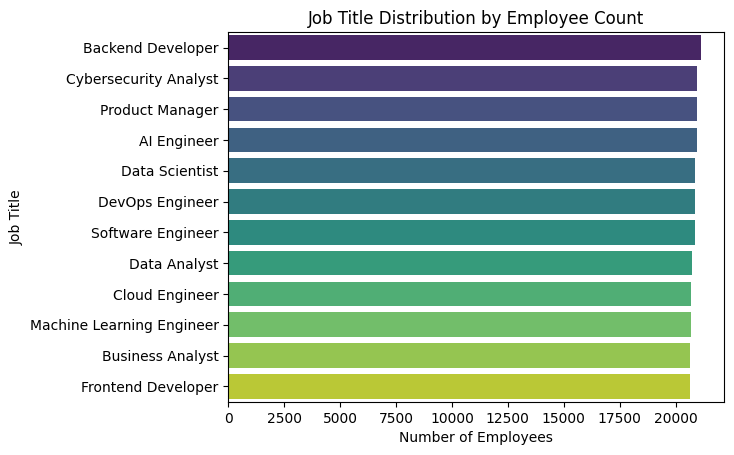

In [27]:
# Most Common Job Titles
job_counts = df['job_title'].value_counts()
sns.barplot(x=job_counts.values, y=job_counts.index, palette='viridis')
plt.title('Job Title Distribution by Employee Count')
plt.xlabel('Number of Employees')
plt.ylabel('Job Title')
plt.show()

C:\Users\janua\AppData\Local\Temp\ipykernel_49020\687386051.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='job_title', y='salary', data=df, order=job_order, palette='Set1')


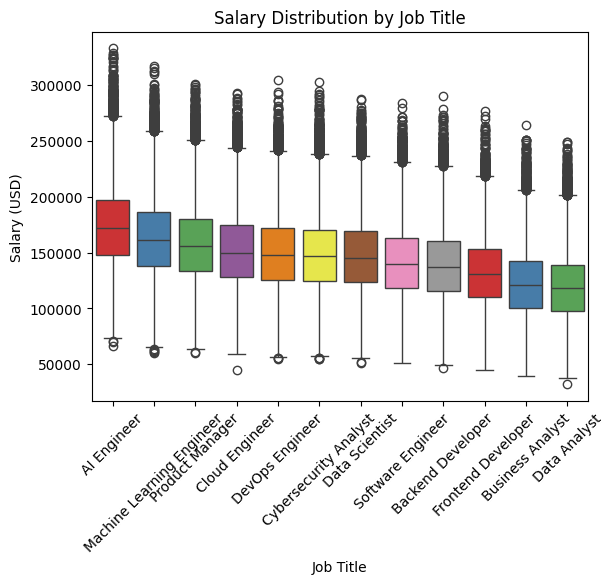

In [28]:
# Salary Distribution by Job Title
job_order = df.groupby('job_title')['salary'].median().sort_values(ascending=False).index
sns.boxplot(x='job_title', y='salary', data=df, order=job_order, palette='Set1')
plt.title('Salary Distribution by Job Title')
plt.xlabel('Job Title')
plt.ylabel('Salary (USD)')
plt.xticks(rotation=45)
plt.show()

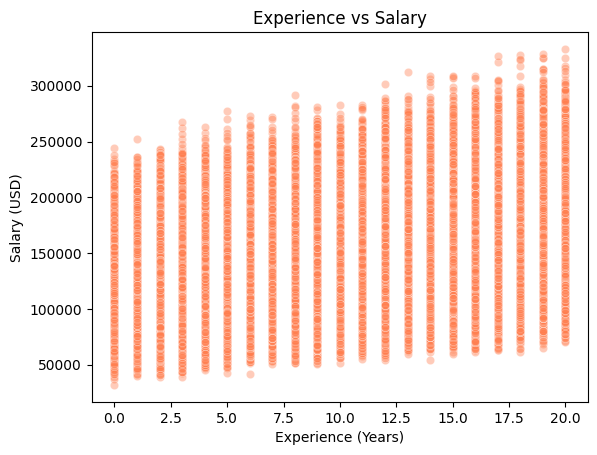

In [29]:

sns.scatterplot(x='experience_years', y='salary', data=df, alpha=0.4, color='coral')
plt.title('Experience vs Salary')
plt.xlabel('Experience (Years)')
plt.ylabel('Salary (USD)')
plt.show()


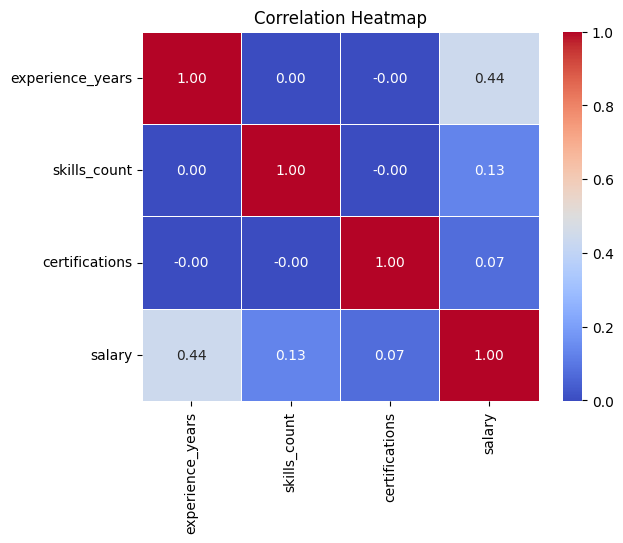

In [30]:
# Correlation Heatmap
numeric_df = df[['experience_years', 'skills_count', 'certifications', 'salary']]
sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=True, fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

C:\Users\janua\AppData\Local\Temp\ipykernel_49020\3242273599.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr.index, y=corr.values, palette='Blues_r')


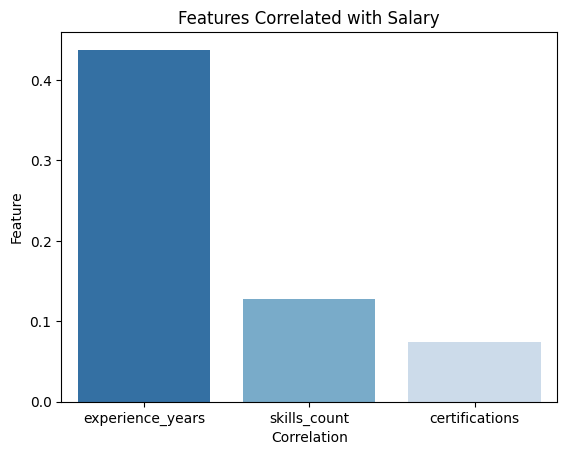

In [34]:
# Top Features Correlated with Salary
numeric_df = df.select_dtypes(include='number')
corr = numeric_df.corr()['salary'].drop('salary').sort_values(ascending=False)
sns.barplot(x=corr.index, y=corr.values, palette='Blues_r')
plt.title('Features Correlated with Salary')
plt.xlabel('Correlation')
plt.ylabel('Feature')
plt.show()

C:\Users\janua\AppData\Local\Temp\ipykernel_49020\698050373.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr.index, y=corr.values, palette='Blues_r')


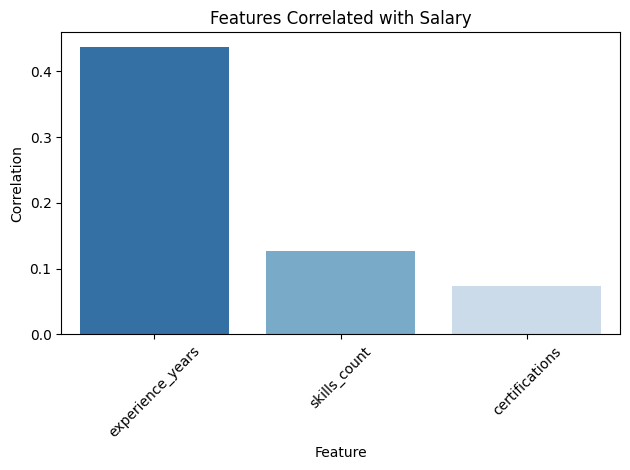

In [32]:
# Top Features Correlated with Salary
numeric_df = df.select_dtypes(include='number')
corr = numeric_df.corr()['salary'].drop('salary').sort_values(ascending=False)
sns.barplot(x=corr.index, y=corr.values, palette='Blues_r')
plt.title('Features Correlated with Salary')
plt.xlabel('Feature')
plt.ylabel('Correlation')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [37]:

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [39]:
# Encode all categorical columns
le = LabelEncoder()

columns = ['job_title', 'education_level', 'industry', 'company_size', 'location', 'remote_work']

for col in columns:
    df[col + '_encoded'] = le.fit_transform(df[col])

# Select features (encoded + original numerical columns)
X = df[['experience_years', 'skills_count', 'certifications',
        'job_title_encoded', 'education_level_encoded', 'industry_encoded',
        'company_size_encoded', 'location_encoded', 'remote_work_encoded']]

y = df['salary']

print("Features:", X.columns.tolist())
print("Shape:", X.shape)



Features: ['experience_years', 'skills_count', 'certifications', 'job_title_encoded', 'education_level_encoded', 'industry_encoded', 'company_size_encoded', 'location_encoded', 'remote_work_encoded']
Shape: (250000, 9)


In [40]:
# Split Data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 200000
Testing samples: 50000


In [41]:
#Train the Model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!
